# Prompt-only vs Teacher-forced ARC Comparison

`analyze_arc_mistake_iterations.ipynb` を軽量化した比較用 notebook です。同じ ARC sample に対して、teacher-forced next-token 評価と prompt-only autoregressive 生成を並べて確認します。

In [1]:
from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from matplotlib.colors import BoundaryNorm, ListedColormap

from autoregressive_eval_URM import _generate_urm_batch, _resolve_casual_token_ids
from evaluate_trained_model import (
    apply_eval_overrides,
    load_config_from_checkpoint,
    _checkpoint_step,
    _resolve_checkpoint_path,
)
from models.losses import IGNORE_LABEL_ID
from pretrain import create_dataloader, init_train_state, _get_loop_config, _load_model_state
from puzzle_dataset import PuzzleDatasetConfig
from puzzle_full_dataset import PuzzleFullDataset

plt.rcParams["figure.dpi"] = 120

In [2]:
# ここを変更してください
CHECKPOINT = "checkpoints/URM-arcagi1-full-gen-l4-casual/step_23828.pt"
DATASET_DIR = None  # None なら checkpoint の config.data_path を使う

SPLIT = "train"  # "train" or "test"
GROUP_ID = 0
PUZZLE_ID = 0
PUZZLE_ID_MODE = "local"  # "local", "absolute", or "auto"
EXAMPLE_ID = 0
EXAMPLE_ID_MODE = "local"  # "local", "absolute", "auto", or "random"
RANDOM_SEED = 0

TRAIN_CONTEXT_COUNT = 3
LOOPS_TO_RUN = 16
PROMPT_ONLY_EXTRA_TOKENS = 20

# train split の複数サンプルをまとめて比較します。重い場合は False にしてください。
RUN_TRAIN_SCAN = True
TRAIN_SCAN_SAMPLE_COUNT = 4

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cuda


In [3]:
ARC_TOKEN_PAD = 0
ARC_TOKEN_EOS = 1
ARC_TOKEN_COLOR_OFFSET = 2
ARC_NUM_TOKENS = 12

ARC_TOKEN_COLORS = [
    "#2D257F", "#E6E6E6", "#000000", "#0074D9", "#FF4136", "#2ECC40",
    "#FFDC00", "#AAAAAA", "#F012BE", "#FF851B", "#7FDBFF", "#870C25",
]
ARC_CMAP = ListedColormap(ARC_TOKEN_COLORS)
ARC_NORM = BoundaryNorm(np.arange(-0.5, ARC_NUM_TOKENS + 0.5, 1.0), ARC_CMAP.N)


def decode_arc_canvas(tokens, shape):
    canvas = np.asarray(tokens, dtype=np.uint8).reshape(tuple(int(x) for x in shape))
    nonzero_rows = np.flatnonzero(np.any(canvas != ARC_TOKEN_PAD, axis=1))
    nonzero_cols = np.flatnonzero(np.any(canvas != ARC_TOKEN_PAD, axis=0))
    if nonzero_rows.size == 0 or nonzero_cols.size == 0:
        return np.zeros((1, 1), dtype=np.uint8)
    active = canvas[: int(nonzero_rows[-1]) + 1, : int(nonzero_cols[-1]) + 1]
    eos_rows = np.flatnonzero(np.any(active == ARC_TOKEN_EOS, axis=1) & ~np.any(active >= ARC_TOKEN_COLOR_OFFSET, axis=1))
    eos_cols = np.flatnonzero(np.any(active == ARC_TOKEN_EOS, axis=0) & ~np.any(active >= ARC_TOKEN_COLOR_OFFSET, axis=0))
    grid_h = int(eos_rows[0]) if eos_rows.size else active.shape[0]
    grid_w = int(eos_cols[0]) if eos_cols.size else active.shape[1]
    cropped = active[:grid_h, :grid_w]
    if cropped.size == 0:
        return np.zeros((1, 1), dtype=np.uint8)
    return cropped.astype(np.uint8)


def render_grid(ax, grid, title, wrong_mask=None):
    grid = np.asarray(grid)
    ax.imshow(grid, cmap=ARC_CMAP, norm=ARC_NORM, interpolation="nearest")
    ax.set_title(f"{title}\n{grid.shape[0]}x{grid.shape[1]}", fontsize=10)
    ax.set_xticks(np.arange(-0.5, grid.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid.shape[0], 1), minor=True)
    ax.grid(which="minor", color="#222222", linewidth=0.45)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
    ax.set_aspect("equal")
    if wrong_mask is not None:
        ys, xs = np.where(wrong_mask)
        ax.scatter(xs, ys, marker="x", s=70, linewidths=1.4, color="white")
        ax.scatter(xs, ys, marker="x", s=38, linewidths=1.1, color="#D62728")


def tokens_to_grid(tokens, shape):
    return decode_arc_canvas(np.asarray(tokens, dtype=np.int64), shape)

In [4]:
def load_split_arrays(dataset_dir: Path, split: str):
    split_dir = dataset_dir / split
    with (split_dir / "dataset.json").open() as f:
        metadata = json.load(f)
    data = {
        "split": split,
        "metadata": metadata,
        "inputs": np.load(split_dir / "all__inputs.npy", mmap_mode="r"),
        "labels": np.load(split_dir / "all__labels.npy", mmap_mode="r"),
        "seq_offsets": np.load(split_dir / "all__seq_offsets.npy"),
        "label_seq_offsets": np.load(split_dir / "all__label_seq_offsets.npy"),
        "seq_shapes": np.load(split_dir / "all__seq_shapes.npy"),
        "label_seq_shapes": np.load(split_dir / "all__label_seq_shapes.npy"),
        "puzzle_indices": np.load(split_dir / "all__puzzle_indices.npy"),
        "group_indices": np.load(split_dir / "all__group_indices.npy"),
        "puzzle_identifiers": np.load(split_dir / "all__puzzle_identifiers.npy"),
    }
    examples_path = split_dir / "all__examples.npy"
    example_shapes_path = split_dir / "all__example_shapes.npy"
    if examples_path.exists() and example_shapes_path.exists():
        data["examples"] = np.load(examples_path, allow_pickle=True)
        data["example_shapes"] = np.load(example_shapes_path, allow_pickle=True)
    return data


def resolve_puzzle_index(split_data, group_id, puzzle_id, mode="local"):
    group_indices = split_data["group_indices"]
    if not (0 <= group_id < len(group_indices) - 1):
        raise IndexError(f"GROUP_ID={group_id} is out of range [0, {len(group_indices) - 2}]")
    group_start = int(group_indices[group_id])
    group_end = int(group_indices[group_id + 1])
    group_size = group_end - group_start
    if mode == "local":
        if not (0 <= puzzle_id < group_size):
            raise IndexError(f"local PUZZLE_ID={puzzle_id} is out of range [0, {group_size - 1}] for group {group_id}")
        return group_start + int(puzzle_id)
    if mode == "absolute":
        if not (group_start <= puzzle_id < group_end):
            raise IndexError(f"absolute PUZZLE_ID={puzzle_id} is not in group {group_id}; valid [{group_start}, {group_end - 1}]")
        return int(puzzle_id)
    if mode == "auto":
        if group_start <= puzzle_id < group_end:
            return int(puzzle_id)
        if 0 <= puzzle_id < group_size:
            return group_start + int(puzzle_id)
    raise ValueError('PUZZLE_ID_MODE must be "local", "absolute", or "auto"')


def resolve_example_index(split_data, puzzle_index, example_id, mode="local", seed=None):
    start = int(split_data["puzzle_indices"][puzzle_index])
    end = int(split_data["puzzle_indices"][puzzle_index + 1])
    if start >= end:
        raise ValueError(f"puzzle_index={puzzle_index} has no examples")
    if mode == "random":
        return random.Random(seed).randrange(start, end)
    if mode == "local":
        if not (0 <= example_id < end - start):
            raise IndexError(f"local EXAMPLE_ID={example_id} is out of range [0, {end - start - 1}]")
        return start + int(example_id)
    if mode == "absolute":
        if not (start <= example_id < end):
            raise IndexError(f"absolute EXAMPLE_ID={example_id} is not in puzzle; valid [{start}, {end - 1}]")
        return int(example_id)
    if mode == "auto":
        if start <= example_id < end:
            return int(example_id)
        if 0 <= example_id < end - start:
            return start + int(example_id)
    raise ValueError('EXAMPLE_ID_MODE must be "local", "absolute", "auto", or "random"')


def identifier_name(dataset_dir: Path, split_data, puzzle_index):
    with (dataset_dir / "identifiers.json").open() as f:
        identifiers = json.load(f)
    ident = int(split_data["puzzle_identifiers"][puzzle_index])
    return identifiers[ident] if 0 <= ident < len(identifiers) else f"<unknown:{ident}>"


def target_solution_tokens(split_data, example_index):
    start = int(split_data["label_seq_offsets"][example_index])
    end = int(split_data["label_seq_offsets"][example_index + 1])
    return torch.from_numpy(split_data["labels"][start:end].astype(np.int64, copy=False))


def target_solution_shape(split_data, example_index):
    return tuple(int(v) for v in split_data["label_seq_shapes"][example_index])

In [5]:
def resolve_dataset_forward_mode(config):
    mode = getattr(getattr(config, "arch", None), "forward_mode", None)
    if mode is None:
        mode = getattr(config, "forward_mode", None)
    return "standard" if mode is None else str(mode)


def make_full_dataset(config, split):
    forward_mode = resolve_dataset_forward_mode(config)
    ds = PuzzleFullDataset(
        PuzzleDatasetConfig(
            seed=config.seed,
            dataset_path=config.data_path,
            global_batch_size=1,
            test_set_mode=(split == "test"),
            epochs_per_iter=1,
            grad_accum_steps=1,
            rank=0,
            num_replicas=1,
            data_fraction=1.0,
            examples_per_puzzle=config.examples_per_puzzle,
            online_aug=None,
            masked_input=config.masked_input,
            arc_output_mask=None,
            full_min_pairs=config.full_min_pairs,
            full_max_pairs=config.full_max_pairs,
            full_answer_initial_mode=config.full_answer_initial_mode,
            full_answer_initial_black_token_id=config.full_answer_initial_black_token_id,
            full_answer_initial_gamma_min=config.full_answer_initial_gamma_min,
            full_answer_initial_gamma_max=config.full_answer_initial_gamma_max,
            full_answer_initial_noise_token_min=config.full_answer_initial_noise_token_min,
            full_answer_initial_noise_token_max=config.full_answer_initial_noise_token_max,
            full_casual_skip_loss_pairs=config.full_casual_skip_loss_pairs,
            forward_mode=forward_mode,
            casual=forward_mode in {"prefix_lm", "casual"},
            answer_only_labels=bool(getattr(config.arch, "answer_only", False)),
        ),
        split=split,
    )
    ds._lazy_load_dataset()
    return ds


def select_train_example_indices(split_data, puzzle_index, example_index, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    start = int(split_data["puzzle_indices"][puzzle_index])
    end = int(split_data["puzzle_indices"][puzzle_index + 1])
    candidates = [i for i in range(start, end) if i != example_index]
    if len(candidates) < TRAIN_CONTEXT_COUNT:
        chosen_context = candidates
    else:
        chosen_context = rng.choice(candidates, size=TRAIN_CONTEXT_COUNT, replace=False).tolist()
    return np.array(chosen_context + [int(example_index)], dtype=np.int64)


def build_sample(ds, split_data, puzzle_index, example_index, *, prompt_only, seed=RANDOM_SEED):
    dataset = ds._data["all"]
    rng = np.random.default_rng(seed)
    puzzle_identifier = np.array([int(split_data["puzzle_identifiers"][puzzle_index])], dtype=np.int64)
    old_split = ds.split
    try:
        if split_data["split"] == "test":
            ds.split = "eval" if prompt_only else "train"
            sample = ds._build_test_sample(dataset, int(example_index), rng=rng)
        else:
            selected = select_train_example_indices(split_data, puzzle_index, example_index, seed=seed)
            ds.split = "eval_train" if prompt_only else "train"
            sample = ds._build_full_sample(dataset, selected, rng, target_pair_index=len(selected) - 1)
        return ds._collate_built_samples([sample], puzzle_identifier)
    finally:
        ds.split = old_split

In [6]:
if DEVICE != "cuda":
    raise RuntimeError("この notebook は CUDA 前提です。CUDA 環境で実行してください。")

resolved_checkpoint = _resolve_checkpoint_path(CHECKPOINT)
if resolved_checkpoint is None:
    raise FileNotFoundError(f"Could not resolve checkpoint path from: {CHECKPOINT}")
checkpoint_path = Path(resolved_checkpoint)

config = load_config_from_checkpoint(str(checkpoint_path))
apply_eval_overrides(config, batch_size=1, loops=LOOPS_TO_RUN, hidden_diff_threshold=None)
config.checkpoint_path = str(checkpoint_path.parent)
dataset_dir = Path(config.data_path if DATASET_DIR is None else DATASET_DIR)
config.data_path = str(dataset_dir)
config.torch_compile = False

split_data = load_split_arrays(dataset_dir, SPLIT)
full_ds = make_full_dataset(config, SPLIT)
puzzle_index = resolve_puzzle_index(split_data, GROUP_ID, PUZZLE_ID, PUZZLE_ID_MODE)
example_index = resolve_example_index(split_data, puzzle_index, EXAMPLE_ID, EXAMPLE_ID_MODE, RANDOM_SEED)
name = identifier_name(dataset_dir, split_data, puzzle_index)

print("checkpoint:", checkpoint_path)
print("dataset:", dataset_dir)
print("forward_mode:", resolve_dataset_forward_mode(config))
print(f"split={SPLIT} group={GROUP_ID} puzzle_index={puzzle_index} identifier={name} example_index={example_index}")

checkpoint: checkpoints/URM-arcagi1-full-gen-l4-casual/step_23828.pt
dataset: data/arc1withgen-aug-1000
forward_mode: casual
split=train group=0 puzzle_index=0 identifier=8be77c9e example_index=0


In [7]:
torch.random.manual_seed(config.seed)
train_loader, train_metadata = create_dataloader(
    config,
    "train",
    rank=0,
    world_size=1,
    test_set_mode=False,
    epochs_per_iter=1,
    global_batch_size=1,
)
train_state = init_train_state(config, train_metadata, rank=0, world_size=1)

checkpoint = torch.load(checkpoint_path, map_location="cuda")
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
    step = checkpoint.get("step")
else:
    state_dict = checkpoint
    step = None
if not config.torch_compile and any(k.startswith("_orig_mod.") for k in state_dict):
    state_dict = {k.removeprefix("_orig_mod."): v for k, v in state_dict.items()}
    print("stripped _orig_mod. prefix from compiled checkpoint weights")
_load_model_state(train_state, config, state_dict, rank=0)
train_state.step = int(step) if step is not None else _checkpoint_step(checkpoint_path)
train_state.carry = None
train_state.accum_carries = None
train_state.accum_metrics = None
train_state.model.eval()

loop_config = _get_loop_config(train_state.model)
if loop_config is not None:
    loop_config.loops = LOOPS_TO_RUN

base_model = getattr(train_state.model, "model", train_state.model)
start_token_id, end_token_id = _resolve_casual_token_ids(config, base_model, train_metadata)
del train_loader
print("model loaded")
print("model_checkpoint_loops:", getattr(loop_config, "loops", None))
print("START_TOKEN:", start_token_id, "END_TOKEN:", end_token_id)

Dataset train has 960 groups.
Dataset uses casual causal-LM ARC tokens without 30x30 answer padding.
Created dataloader for split 'train'.
torch.compile disabled
stripped _orig_mod. prefix from compiled checkpoint weights
model loaded
model_checkpoint_loops: 16
START_TOKEN: 13 END_TOKEN: 12


In [8]:
def first_mismatch(target, generated):
    common = min(int(target.numel()), int(generated.numel()))
    for idx in range(common):
        if int(target[idx]) != int(generated[idx]):
            return {"index": idx, "target": int(target[idx]), "generated": int(generated[idx])}
    if int(target.numel()) != int(generated.numel()):
        return {"index": common, "target": "<end>" if common >= int(target.numel()) else int(target[common]), "generated": "<end>" if common >= int(generated.numel()) else int(generated[common])}
    return None


def run_teacher_forced(batch_cpu, target_tokens):
    batch = {k: v.cuda() for k, v in batch_cpu.items()}
    with torch.inference_mode(), torch.device("cuda"):
        carry = train_state.model.initial_carry(batch)
        preds = None
        for _ in range(LOOPS_TO_RUN):
            carry, loss, metrics, preds, all_finish = train_state.model(
                carry=carry,
                batch=batch,
                return_keys={"logits", "preds", "q_halt_logits", "q_continue_logits"},
            )
        labels = batch["labels"].detach().cpu()
        pred_tokens = preds["preds"].detach().cpu()
    if "answer_mask" in batch_cpu and bool(batch_cpu["answer_mask"].any().item()):
        mask = batch_cpu["answer_mask"].detach().cpu().bool()
    else:
        mask = labels != IGNORE_LABEL_ID
    teacher_labels = labels[mask]
    teacher_preds = pred_tokens[mask]
    content_len = int(target_tokens.numel())
    content_pred = teacher_preds[:content_len]
    content_label = teacher_labels[:content_len]
    content_acc = float((content_pred == content_label).float().mean().item()) if content_len else 0.0
    end_correct = bool(teacher_preds.numel() > content_len and int(teacher_preds[content_len]) == int(end_token_id))
    return {
        "content_tokens": content_pred,
        "content_accuracy": content_acc,
        "content_exact": bool(torch.equal(content_pred, target_tokens)),
        "end_correct": end_correct,
        "raw_pred_len": int(teacher_preds.numel()),
    }


def run_prompt_only(batch_cpu, target_tokens):
    batch = {k: v.cuda() for k, v in batch_cpu.items()}
    max_new_tokens = int(target_tokens.numel()) + int(PROMPT_ONLY_EXTRA_TOKENS)
    with torch.inference_mode():
        final_batch, preds, _sample_metrics = _generate_urm_batch(
            base_model,
            batch,
            start_token_id=start_token_id,
            end_token_id=end_token_id,
            newline_token_id=ARC_TOKEN_EOS,
            max_new_tokens=max_new_tokens,
            cache_chunk_size=int(config.autoregressive_eval_cache_chunk_size),
        )[0]
    answer_mask = final_batch["answer_mask"].detach().cpu().bool()
    generated = preds["preds"].detach().cpu()[answer_mask]
    common = min(int(generated.numel()), int(target_tokens.numel()))
    prefix_acc = float((generated[:common] == target_tokens[:common]).float().mean().item()) if common else 0.0
    return {
        "content_tokens": generated,
        "prefix_accuracy": prefix_acc,
        "content_exact": bool(generated.numel() == target_tokens.numel() and torch.equal(generated, target_tokens)),
        "ended_before_limit": int(generated.numel()) < max_new_tokens,
        "generated_len": int(generated.numel()),
        "max_new_tokens": max_new_tokens,
    }


def compare_one(puzzle_index, example_index, seed=RANDOM_SEED):
    target_tokens = target_solution_tokens(split_data, example_index)
    teacher_batch = build_sample(full_ds, split_data, puzzle_index, example_index, prompt_only=False, seed=seed)
    prompt_batch = build_sample(full_ds, split_data, puzzle_index, example_index, prompt_only=True, seed=seed)
    teacher = run_teacher_forced(teacher_batch, target_tokens)
    prompt = run_prompt_only(prompt_batch, target_tokens)
    return {
        "puzzle_index": int(puzzle_index),
        "example_index": int(example_index),
        "target_len": int(target_tokens.numel()),
        "teacher_content_accuracy": teacher["content_accuracy"],
        "teacher_content_exact": teacher["content_exact"],
        "teacher_end_correct": teacher["end_correct"],
        "prompt_prefix_accuracy": prompt["prefix_accuracy"],
        "prompt_exact": prompt["content_exact"],
        "prompt_generated_len": prompt["generated_len"],
        "prompt_ended_before_limit": prompt["ended_before_limit"],
        "teacher_first_mismatch": first_mismatch(target_tokens, teacher["content_tokens"]),
        "prompt_first_mismatch": first_mismatch(target_tokens, prompt["content_tokens"]),
        "target_tokens": target_tokens,
        "teacher_tokens": teacher["content_tokens"],
        "prompt_tokens": prompt["content_tokens"],
    }

In [9]:
comparison = compare_one(puzzle_index, example_index, seed=RANDOM_SEED)
summary = {k: v for k, v in comparison.items() if not k.endswith("_tokens")}
try:
    import pandas as pd
    display(pd.DataFrame([summary]))
except Exception:
    print(summary)

print("target first 32:", comparison["target_tokens"][:32].tolist())
print("teacher first 32:", comparison["teacher_tokens"][:32].tolist())
print("prompt first 32:", comparison["prompt_tokens"][:32].tolist())

,puzzle_index,example_index,target_len,teacher_content_accuracy,teacher_content_exact,teacher_end_correct,prompt_prefix_accuracy,prompt_exact,prompt_generated_len,prompt_ended_before_limit,teacher_first_mismatch,prompt_first_mismatch
0,0,0,28,1.0,True,True,0.964286,False,48,False,None,"{'index': 27, 'target': 0, 'generated': 1}"


target first 32: [2, 2, 2, 1, 2, 2, 3, 1, 3, 2, 2, 1, 3, 2, 2, 1, 2, 2, 3, 1, 2, 2, 2, 1, 1, 1, 1, 0]
teacher first 32: [2, 2, 2, 1, 2, 2, 3, 1, 3, 2, 2, 1, 3, 2, 2, 1, 2, 2, 3, 1, 2, 2, 2, 1, 1, 1, 1, 0]
prompt first 32: [2, 2, 2, 1, 2, 2, 3, 1, 3, 2, 2, 1, 3, 2, 2, 1, 2, 2, 3, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [10]:
def choose_train_scan_examples(split_data, max_samples):
    rows = []
    num_groups = len(split_data["group_indices"]) - 1
    for group_id in range(num_groups):
        group_start = int(split_data["group_indices"][group_id])
        group_end = int(split_data["group_indices"][group_id + 1])
        for pi in range(group_start, group_end):
            start = int(split_data["puzzle_indices"][pi])
            end = int(split_data["puzzle_indices"][pi + 1])
            if end - start >= 2:
                rows.append((group_id, pi, start))
                break
        if len(rows) >= max_samples:
            break
    return rows


if RUN_TRAIN_SCAN:
    if SPLIT != "train":
        print("Skipping train scan because SPLIT is not 'train'.")
    else:
        scan_rows = []
        for sample_idx, (group_id, pi, ei) in enumerate(choose_train_scan_examples(split_data, TRAIN_SCAN_SAMPLE_COUNT)):
            item = compare_one(pi, ei, seed=RANDOM_SEED + sample_idx)
            scan_rows.append(
                {
                    "sample": sample_idx,
                    "group": group_id,
                    "puzzle_index": pi,
                    "example_index": ei,
                    "target_len": item["target_len"],
                    "teacher_acc": item["teacher_content_accuracy"],
                    "teacher_exact": item["teacher_content_exact"],
                    "teacher_end": item["teacher_end_correct"],
                    "prompt_acc": item["prompt_prefix_accuracy"],
                    "prompt_exact": item["prompt_exact"],
                    "prompt_len": item["prompt_generated_len"],
                    "prompt_ended": item["prompt_ended_before_limit"],
                    "prompt_mismatch": item["prompt_first_mismatch"],
                }
            )
        try:
            import pandas as pd
            scan_df = pd.DataFrame(scan_rows)
            display(scan_df)
            display(scan_df[["teacher_acc", "teacher_exact", "teacher_end", "prompt_acc", "prompt_exact", "prompt_ended"]].mean(numeric_only=True))
        except Exception:
            for row in scan_rows:
                print(row)

,sample,group,puzzle_index,example_index,target_len,teacher_acc,teacher_exact,teacher_end,prompt_acc,prompt_exact,prompt_len,prompt_ended,prompt_mismatch
0,0,0,0,0,28,1.000000,True,True,0.964286,False,48,False,"{'index': 27, 'target': 0, 'generated': 1}"
1,1,1,72,19152,196,0.994898,False,True,0.954082,False,216,False,"{'index': 3, 'target': 2, 'generated': 8}"
2,2,2,1072,285152,100,0.990000,False,True,0.850000,False,120,False,"{'index': 1, 'target': 2, 'generated': 10}"
3,3,3,2072,552152,50,1.000000,True,True,0.980000,False,70,False,"{'index': 49, 'target': 0, 'generated': 1}"


teacher_acc      0.996224
teacher_exact    0.500000
teacher_end      1.000000
prompt_acc       0.937092
prompt_exact     0.000000
prompt_ended     0.000000
dtype: float64

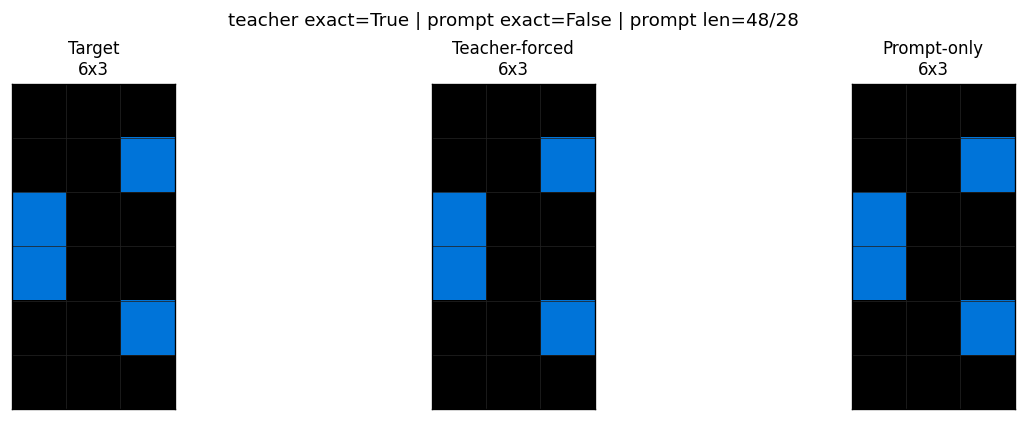

In [11]:
shape = target_solution_shape(split_data, example_index)
target_grid = tokens_to_grid(comparison["target_tokens"], shape)
teacher_grid = tokens_to_grid(comparison["teacher_tokens"][: comparison["target_len"]], shape)
prompt_padded = torch.full_like(comparison["target_tokens"], ARC_TOKEN_PAD)
copy_len = min(int(prompt_padded.numel()), int(comparison["prompt_tokens"].numel()))
if copy_len:
    prompt_padded[:copy_len] = comparison["prompt_tokens"][:copy_len]
prompt_grid = tokens_to_grid(prompt_padded, shape)

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.4), constrained_layout=True)
render_grid(axes[0], target_grid, "Target")
render_grid(axes[1], teacher_grid, "Teacher-forced", wrong_mask=(teacher_grid != target_grid))
render_grid(axes[2], prompt_grid, "Prompt-only", wrong_mask=(prompt_grid != target_grid))
fig.suptitle(
    f"teacher exact={comparison['teacher_content_exact']} | prompt exact={comparison['prompt_exact']} | "
    f"prompt len={comparison['prompt_generated_len']}/{comparison['target_len']}",
    fontsize=11,
)
plt.show()